# BTC Price Forecasting
## Notebook 2  Preprocessing

This notebook transforms the raw Coinbase CSV into clean, scaled arrays
ready to feed directly into the model. Every decision applied here was
justified by the findings in Notebook 1.

**Output files written to Drive:**
- `train_scaled.npy`, `val_scaled.npy`, `test_scaled.npy`  scaled feature arrays
- `scaler.pkl`  fitted MinMaxScaler for inverse-transforming predictions to USD

**Pipeline steps:**
1. Load and reindex — rebuild the complete 60-second DatetimeIndex
2. Forward-fill — fill all NaN rows in a single pass
3. Trim — remove everything before 2017-01-01
4. Feature engineering — log volume, cyclic time encodings
5. Temporal split — train / val / test by date, never randomly
6. Fit and save scaler — MinMaxScaler fitted on training data only
7. Scale — transform all three splits
8. Save — write arrays and scaler to Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pickle
import os

DATA_PATH  = '/content/drive/MyDrive/BitcoinProject/coinbaseUSD_1-min_data_2014-12-01_to_2019-01-09.csv'
DRIVE_PATH = '/content/drive/MyDrive/BitcoinProject/'
os.makedirs(DRIVE_PATH, exist_ok=True)

WINDOW_SIZE = 1440
HORIZON     = 1
TRIM_START  = '2017-01-01'
TRAIN_END   = '2018-07-01'
VAL_END     = '2018-10-15'
CLOSE_IDX   = 0
FEATURES    = ['Close', 'volume_log', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

print('Libraries loaded ✓')
print(f'Output directory: {DRIVE_PATH}')

Mounted at /content/drive
Libraries loaded ✓
Output directory: /content/drive/MyDrive/BitcoinProject/


## Load and Reindex

The raw CSV is loaded and immediately reindexed against a complete 60-second
DatetimeIndex. This surfaces the 58,354 timestamps that are absent from the
CSV entirely, making them visible as NaN rows before the forward-fill pass.

In [2]:
print('Loading raw data...')
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'  Loaded: {len(df):,} rows')

df['datetime'] = pd.to_datetime(df['Timestamp'], unit='s')
df = df.set_index('datetime').sort_index()

full_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='60s'
)
df = df.reindex(full_index)

print(f'  Rows after reindex : {len(df):,}')
print(f'  NaN rows surfaced  : {df["Close"].isna().sum():,}')
print(f'  Date range         : {df.index.min()} → {df.index.max()}')
print('Reindex complete ')

Loading raw data...
  Loaded: 2,099,760 rows
  Rows after reindex : 2,158,114
  NaN rows surfaced  : 167,423
  Date range         : 2014-12-01 05:33:00 → 2019-01-07 22:06:00
Reindex complete 


## Forward-fill

All NaN rows are now visible. A single forward-fill pass carries the last
known price forward into every inactive minute. Any rows at the very start
of the series with no prior value to fill from are dropped.

In [3]:
nan_before = df['Close'].isna().sum()
df = df.ffill()
nan_after  = df['Close'].isna().sum()

df = df.dropna(subset=['Close'])

print(f'  NaN rows before ffill : {nan_before:,}')
print(f'  NaN rows after ffill  : {nan_after:,}')
print(f'  Rows after dropna     : {len(df):,}')
print('Forward-fill complete ')

  NaN rows before ffill : 167,423
  NaN rows after ffill  : 0
  Rows after dropna     : 2,158,114
Forward-fill complete 


## Trim to 2017-01-01

Everything before 2017-01-01 is removed. The early dataset contains gaps of up
to 38.4 hours that would produce long flat-line artifacts after forward-filling.
Trimming eliminates these entirely and leaves a dense, reliable training set.

In [4]:
rows_before = len(df)
df = df[df.index >= TRIM_START]
rows_after  = len(df)

print(f'  Rows before trim : {rows_before:,}')
print(f'  Rows after trim  : {rows_after:,}')
print(f'  Rows removed     : {rows_before - rows_after:,}')
print(f'  Date range       : {df.index.min()} → {df.index.max()}')
print('Trim complete ')

  Rows before trim : 2,158,114
  Rows after trim  : 1,061,167
  Rows removed     : 1,096,947
  Date range       : 2017-01-01 00:00:00 → 2019-01-07 22:06:00
Trim complete 


## Feature Engineering

The final 6-column feature matrix is constructed from the decisions documented
in Notebook 1.

- **Close**  retained as the primary signal and prediction target
- **volume_log**  log₁p transform of Volume_(BTC) to correct severe right skew
- **hour_sin / hour_cos** cyclic encoding of hour-of-day (period = 24 hours)
- **dow_sin / dow_cos** cyclic encoding of day-of-week (period = 7 days)

All other columns are dropped.

In [5]:
df['volume_log'] = np.log1p(df['Volume_(BTC)'])

hour = df.index.hour + df.index.minute / 60.0
df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * hour / 24)

dow = df.index.dayofweek
df['dow_sin'] = np.sin(2 * np.pi * dow / 7)
df['dow_cos'] = np.cos(2 * np.pi * dow / 7)

df = df[FEATURES]

print(f'  Feature columns : {FEATURES}')
print(f'  Shape           : {df.shape}')
print()
print(df.head(3))
print('Feature engineering complete ✓')

  Feature columns : ['Close', 'volume_log', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']
  Shape           : (1061167, 6)

                      Close  volume_log  hour_sin  hour_cos   dow_sin  dow_cos
2017-01-01 00:00:00  973.35    1.138489  0.000000  1.000000 -0.781831  0.62349
2017-01-01 00:01:00  973.35    1.138489  0.004363  0.999990 -0.781831  0.62349
2017-01-01 00:02:00  973.35    1.138489  0.008727  0.999962 -0.781831  0.62349
Feature engineering complete ✓


## Temporal Split

The dataset is divided into train, validation, and test sets strictly by date.
No shuffling is applied at any stage  shuffling a time series leaks future
price information into the training set, which would invalidate the model entirely.

| Split | Period | Purpose |
|-------|--------|---------|
| Train | 2017-01-01 -> 2018-07-01 | Model learns from this data |
| Validation | 2018-07-01 -> 2018-10-15 | Hyperparameter tuning and early stopping |
| Test | 2018-10-15 -> 2019-01-07 | Final unbiased evaluation |

In [6]:
train_df = df[df.index <  TRAIN_END]
val_df   = df[(df.index >= TRAIN_END) & (df.index < VAL_END)]
test_df  = df[df.index >= VAL_END]

print(f'  Train : {len(train_df):,} rows  ({train_df.index.min().date()} → {train_df.index.max().date()})')
print(f'  Val   : {len(val_df):,} rows  ({val_df.index.min().date()} → {val_df.index.max().date()})')
print(f'  Test  : {len(test_df):,} rows  ({test_df.index.min().date()} → {test_df.index.max().date()})')
print()
print(f'  Train : {len(train_df)/len(df)*100:.1f}%')
print(f'  Val   : {len(val_df)/len(df)*100:.1f}%')
print(f'  Test  : {len(test_df)/len(df)*100:.1f}%')
print('Split complete ')

  Train : 786,240 rows  (2017-01-01 → 2018-06-30)
  Val   : 152,640 rows  (2018-07-01 → 2018-10-14)
  Test  : 122,287 rows  (2018-10-15 → 2019-01-07)

  Train : 74.1%
  Val   : 14.4%
  Test  : 11.5%
Split complete 


## Fit and Save Scaler

The MinMaxScaler is fitted exclusively on the training split. Fitting on the
full dataset would leak the price range of the validation and test periods into
training the model would indirectly know future price levels before ever
seeing them. The fitted scaler is saved to disk so predictions can be
inverse-transformed back to USD in Notebook 3.

In [7]:
scaler      = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df.values)
val_scaled   = scaler.transform(val_df.values)
test_scaled  = scaler.transform(test_df.values)

scaler_path = os.path.join(DRIVE_PATH, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)

print(f'  Scaler fitted on  : {len(train_df):,} rows')
print(f'  Train scaled range: [{train_scaled.min():.4f}, {train_scaled.max():.4f}]')
print(f'  Val scaled range  : [{val_scaled.min():.4f}, {val_scaled.max():.4f}]')
print(f'  Test scaled range : [{test_scaled.min():.4f}, {test_scaled.max():.4f}]')
print(f'  Scaler saved  {scaler_path}')
print('Scaling complete ')

  Scaler fitted on  : 786,240 rows
  Train scaled range: [0.0000, 1.0000]
  Val scaled range  : [0.0000, 1.0000]
  Test scaled range : [0.0000, 1.0000]
  Scaler saved  /content/drive/MyDrive/BitcoinProject/scaler.pkl
Scaling complete 


## Visualizing the Splits

A visual confirmation that the three splits cover distinct non-overlapping
time periods and that the scaled values are well-behaved.

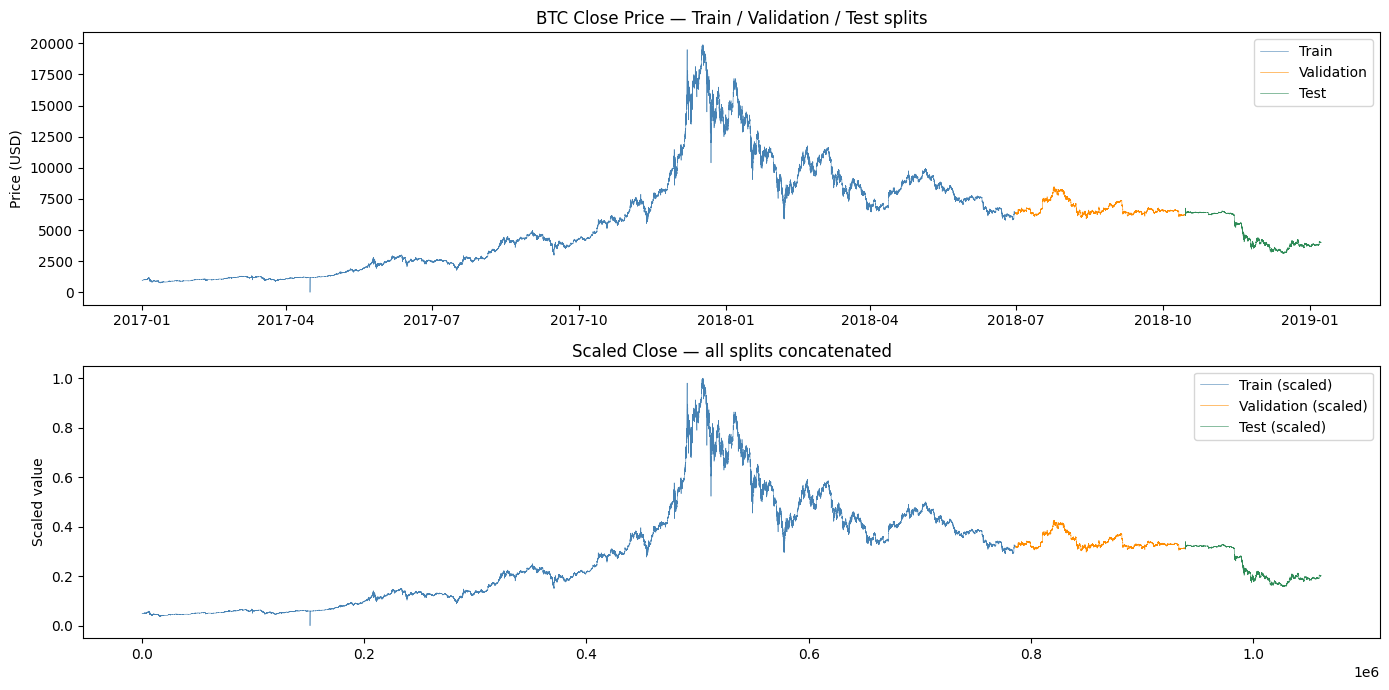

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(train_df.index, train_df['Close'], color='steelblue',
             linewidth=0.4, label='Train')
axes[0].plot(val_df.index,   val_df['Close'],   color='darkorange',
             linewidth=0.4, label='Validation')
axes[0].plot(test_df.index,  test_df['Close'],  color='seagreen',
             linewidth=0.4, label='Test')
axes[0].set_title('BTC Close Price — Train / Validation / Test splits')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

axes[1].plot(train_scaled[:, CLOSE_IDX], color='steelblue',
             linewidth=0.4, label='Train (scaled)')
axes[1].plot(range(len(train_scaled),
                   len(train_scaled) + len(val_scaled)),
             val_scaled[:, CLOSE_IDX],
             color='darkorange', linewidth=0.4, label='Validation (scaled)')
axes[1].plot(range(len(train_scaled) + len(val_scaled),
                   len(train_scaled) + len(val_scaled) + len(test_scaled)),
             test_scaled[:, CLOSE_IDX],
             color='seagreen', linewidth=0.4, label='Test (scaled)')
axes[1].set_title('Scaled Close — all splits concatenated')
axes[1].set_ylabel('Scaled value')
axes[1].legend()

plt.tight_layout()
plt.savefig(DRIVE_PATH + 'splits.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Arrays to Drive

The scaled arrays are saved as `.npy` files. These are the only files
Notebook 3 requires the raw CSV is not needed again from this point on.

In [9]:
np.save(DRIVE_PATH + 'train_scaled.npy', train_scaled)
np.save(DRIVE_PATH + 'val_scaled.npy',   val_scaled)
np.save(DRIVE_PATH + 'test_scaled.npy',  test_scaled)

print(f'  train_scaled.npy  {train_scaled.shape}')
print(f'  val_scaled.npy    {val_scaled.shape}')
print(f'  test_scaled.npy   {test_scaled.shape}')
print(f'  scaler.pkl        already saved in Step 6')
print()
print('Preprocessing complete ')

  train_scaled.npy  (786240, 6)
  val_scaled.npy    (152640, 6)
  test_scaled.npy   (122287, 6)
  scaler.pkl        already saved in Step 6

Preprocessing complete 
